In [2]:
# Import core libraries
import os
import numpy as np
import pandas as pd

# For building the model
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# For preprocessing and visualization
import matplotlib.pyplot as plt


In [3]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [4]:
# Set dataset directory path
DATASET_DIR = "/content/drive/MyDrive/PotatoDiseaseDetection/PlantVillage"

# Quick check to make sure path exists
import os
if os.path.exists(DATASET_DIR):
    print("✅ Dataset directory found")
else:
    print("❌ Dataset directory NOT found. Check the folder path again.")


✅ Dataset directory found


In [5]:
from tensorflow.keras.preprocessing import image_dataset_from_directory

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
VAL_SPLIT = 0.2
SEED = 42

train_ds = image_dataset_from_directory(
    DATASET_DIR,
    validation_split=VAL_SPLIT,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = image_dataset_from_directory(
    DATASET_DIR,
    validation_split=VAL_SPLIT,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# Get class labels
class_names = train_ds.class_names
print("✅ Classes found:", class_names)


Found 2152 files belonging to 3 classes.
Using 1722 files for training.
Found 2152 files belonging to 3 classes.
Using 430 files for validation.
✅ Classes found: ['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']


**Optimize Dataset (Caching + Prefetching)**

In [6]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds   = val_ds.prefetch(buffer_size=AUTOTUNE)

print("✅ Dataset pipeline optimized")


✅ Dataset pipeline optimized


**Data Augmentation + Preprocessing**

In [7]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.1),
], name="data_augmentation")

preprocess = layers.Rescaling(1./255)


train_acc >> val_acc and val_loss rising → overfitting

Both accuracies low → underfitting

Both similar and good → ✅ well-trained

In [8]:
# CELL 1: reproducibility & helpers
import random
import tensorflow as tf
import numpy as np
import os

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

# number of classes
NUM_CLASSES = len(class_names)
print("✅ Num classes:", NUM_CLASSES)

# helper to show training history nicely
def plot_history(history):
    import matplotlib.pyplot as plt
    acc = history.history.get('accuracy', [])
    val_acc = history.history.get('val_accuracy', [])
    loss = history.history.get('loss', [])
    val_loss = history.history.get('val_loss', [])
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.plot(epochs, acc, 'o-', label='train acc')
    plt.plot(epochs, val_acc, 'o--', label='val acc')
    plt.title('Accuracy')
    plt.xlabel('Epoch')
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(epochs, loss, 'o-', label='train loss')
    plt.plot(epochs, val_loss, 'o--', label='val loss')
    plt.title('Loss')
    plt.xlabel('Epoch')
    plt.legend()
    plt.show()


✅ Num classes: 3


Builds a simple CNN suited for small–medium image datasets.

Includes your existing data_augmentation and preprocess layers.

Uses Dropout to prevent overfitting.

Ends with a softmax layer sized by your class count.

In [9]:
# CELL 2: build model
from tensorflow import keras
from tensorflow.keras import layers

input_shape = IMG_SIZE + (3,)

model = keras.Sequential(
    [
        keras.Input(shape=input_shape),
        data_augmentation,        # your augmentation layer
        preprocess,               # your rescaling layer
        layers.Conv2D(32, 3, padding='same', activation='relu'),
        layers.MaxPooling2D(2),
        layers.Conv2D(64, 3, padding='same', activation='relu'),
        layers.MaxPooling2D(2),
        layers.Conv2D(128, 3, padding='same', activation='relu'),
        layers.MaxPooling2D(2),
        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.3),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(NUM_CLASSES, activation='softmax')
    ],
    name="potato_simple_cnn"
)

model.summary()


Model: "potato_simple_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,147 (430.26 KB)

 Trainable params: 110,147 (430.26 KB)

 Non-trainable params: 0 (0.00 B)

Optimizer: Adam with a small learning rate (1e-4) — good balance between stability and speed.

Loss: sparse_categorical_crossentropy → appropriate since your labels are integer-encoded (not one-hot).

Metric: Accuracy → for tracking both training and validation performance.

In [10]:
# CELL 3: compile
from tensorflow import keras

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("✅ Model compiled successfully")


✅ Model compiled successfully


ModelCheckpoint — saves the model weights when validation accuracy improves.

ReduceLROnPlateau — halves the learning rate when validation loss stops improving for 3 epochs.

EarlyStopping — halts training when no improvement in validation accuracy is seen for 8 epochs (prevents overfitting).

In [11]:
# CELL 4: callbacks
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping
import os

CHECKPOINT_PATH = "/content/drive/MyDrive/PotatoDiseaseDetection/checkpoints"
os.makedirs(CHECKPOINT_PATH, exist_ok=True)

checkpoint_cb = ModelCheckpoint(
    filepath=os.path.join(CHECKPOINT_PATH, "best_model.h5"),
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

reduce_lr_cb = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

earlystop_cb = EarlyStopping(
    monitor="val_accuracy",
    patience=8,
    restore_best_weights=True,
    verbose=1
)

callbacks = [checkpoint_cb, reduce_lr_cb, earlystop_cb]
print("✅ Callbacks ready")


✅ Callbacks ready


This ensures your dataset is correctly loaded and split — it confirms:

The number of batches TensorFlow “sees” in each dataset.

That shuffling and batching have been applied properly.

In [12]:
# CELL 5: check dataset and batch counts
train_count = tf.data.experimental.cardinality(train_ds).numpy()
val_count = tf.data.experimental.cardinality(val_ds).numpy()

print(f"✅ Train batches: {train_count}")
print(f"✅ Validation batches: {val_count}")
print(f"Each batch has {BATCH_SIZE} images of size {IMG_SIZE}")


✅ Train batches: 54
✅ Validation batches: 14
Each batch has 32 images of size (224, 224)


train_ds / val_ds → feed your preprocessed and augmented datasets into the model.

EPOCHS → how many full passes through the dataset the model will make.

callbacks → automatically handle saving, learning rate adjustments, and early stopping.

In [13]:
# CELL 6: train the model
EPOCHS = 30  # you can adjust (e.g., 20–50 depending on dataset size)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

print("✅ Training completed successfully")


Epoch 1/30
53/54 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.3762 - loss: 1.0776
Epoch 1: val_accuracy improved from -inf to 0.42326, saving model to /content/drive/MyDrive/PotatoDiseaseDetection/checkpoints/best_model.h5


54/54 ━━━━━━━━━━━━━━━━━━━━ 328s 1s/step - accuracy: 0.3796 - loss: 1.0758 - val_accuracy: 0.4233 - val_loss: 0.9562 - learning_rate: 1.0000e-04
Epoch 2/30
53/54 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.4833 - loss: 0.9048
Epoch 2: val_accuracy did not improve from 0.42326
54/54 ━━━━━━━━━━━━━━━━━━━━ 10s 73ms/step - accuracy: 0.4835 - loss: 0.9043 - val_accuracy: 0.4233 - val_loss: 0.9522 - learning_rate: 1.0000e-04
Epoch 3/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.5050 - loss: 0.8698
Epoch 3: val_accuracy improved from 0.42326 to 0.43256, saving model to /content/drive/MyDrive/PotatoDiseaseDetection/checkpoints/best_model.h5


54/54 ━━━━━━━━━━━━━━━━━━━━ 11s 103ms/step - accuracy: 0.5050 - loss: 0.8699 - val_accuracy: 0.4326 - val_loss: 0.9376 - learning_rate: 1.0000e-04
Epoch 4/30
53/54 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.5336 - loss: 0.8513
Epoch 4: val_accuracy improved from 0.43256 to 0.48372, saving model to /content/drive/MyDrive/PotatoDiseaseDetection/checkpoints/best_model.h5


54/54 ━━━━━━━━━━━━━━━━━━━━ 9s 74ms/step - accuracy: 0.5339 - loss: 0.8516 - val_accuracy: 0.4837 - val_loss: 0.9115 - learning_rate: 1.0000e-04
Epoch 5/30
53/54 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.5694 - loss: 0.8520
Epoch 5: val_accuracy improved from 0.48372 to 0.56744, saving model to /content/drive/MyDrive/PotatoDiseaseDetection/checkpoints/best_model.h5


54/54 ━━━━━━━━━━━━━━━━━━━━ 10s 85ms/step - accuracy: 0.5705 - loss: 0.8509 - val_accuracy: 0.5674 - val_loss: 0.8736 - learning_rate: 1.0000e-04
Epoch 6/30
53/54 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.6591 - loss: 0.7875
Epoch 6: val_accuracy did not improve from 0.56744
54/54 ━━━━━━━━━━━━━━━━━━━━ 10s 74ms/step - accuracy: 0.6592 - loss: 0.7868 - val_accuracy: 0.5488 - val_loss: 0.9037 - learning_rate: 1.0000e-04
Epoch 7/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.6923 - loss: 0.7266
Epoch 7: val_accuracy improved from 0.56744 to 0.70930, saving model to /content/drive/MyDrive/PotatoDiseaseDetection/checkpoints/best_model.h5


54/54 ━━━━━━━━━━━━━━━━━━━━ 10s 97ms/step - accuracy: 0.6925 - loss: 0.7264 - val_accuracy: 0.7093 - val_loss: 0.7563 - learning_rate: 1.0000e-04
Epoch 8/30
53/54 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.7415 - loss: 0.6818
Epoch 8: val_accuracy did not improve from 0.70930
54/54 ━━━━━━━━━━━━━━━━━━━━ 9s 75ms/step - accuracy: 0.7414 - loss: 0.6812 - val_accuracy: 0.5977 - val_loss: 0.8773 - learning_rate: 1.0000e-04
Epoch 9/30
53/54 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.7383 - loss: 0.6557
Epoch 9: val_accuracy improved from 0.70930 to 0.73023, saving model to /content/drive/MyDrive/PotatoDiseaseDetection/checkpoints/best_model.h5


54/54 ━━━━━━━━━━━━━━━━━━━━ 11s 87ms/step - accuracy: 0.7385 - loss: 0.6547 - val_accuracy: 0.7302 - val_loss: 0.6735 - learning_rate: 1.0000e-04
Epoch 10/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.7863 - loss: 0.5915
Epoch 10: val_accuracy did not improve from 0.73023
54/54 ━━━━━━━━━━━━━━━━━━━━ 10s 75ms/step - accuracy: 0.7865 - loss: 0.5911 - val_accuracy: 0.6837 - val_loss: 0.7033 - learning_rate: 1.0000e-04
Epoch 11/30
53/54 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.7891 - loss: 0.5633
Epoch 11: val_accuracy did not improve from 0.73023
54/54 ━━━━━━━━━━━━━━━━━━━━ 10s 84ms/step - accuracy: 0.7899 - loss: 0.5619 - val_accuracy: 0.6814 - val_loss: 0.7394 - learning_rate: 1.0000e-04
Epoch 12/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.8138 - loss: 0.5044
Epoch 12: val_accuracy did not improve from 0.73023

Epoch 12: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
54/54 ━━━━━━━━━━━━━━━━━━━━ 9s 75ms/step - accuracy: 0.8140 - loss: 0.5042

54/54 ━━━━━━━━━━━━━━━━━━━━ 11s 89ms/step - accuracy: 0.8660 - loss: 0.4306 - val_accuracy: 0.7349 - val_loss: 0.6360 - learning_rate: 5.0000e-05
Epoch 14/30
53/54 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.8742 - loss: 0.4169
Epoch 14: val_accuracy did not improve from 0.73488
54/54 ━━━━━━━━━━━━━━━━━━━━ 11s 98ms/step - accuracy: 0.8740 - loss: 0.4170 - val_accuracy: 0.7326 - val_loss: 0.6488 - learning_rate: 5.0000e-05
Epoch 15/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.8676 - loss: 0.4104
Epoch 15: val_accuracy did not improve from 0.73488
54/54 ━━━━━━━━━━━━━━━━━━━━ 11s 99ms/step - accuracy: 0.8676 - loss: 0.4102 - val_accuracy: 0.6721 - val_loss: 0.8275 - learning_rate: 5.0000e-05
Epoch 16/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.8759 - loss: 0.3849
Epoch 16: val_accuracy did not improve from 0.73488

Epoch 16: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-05.
54/54 ━━━━━━━━━━━━━━━━━━━━ 9s 76ms/step - accuracy: 0.8758 - loss: 0.3850

54/54 ━━━━━━━━━━━━━━━━━━━━ 10s 98ms/step - accuracy: 0.8913 - loss: 0.3426 - val_accuracy: 0.7488 - val_loss: 0.6349 - learning_rate: 2.5000e-05
Epoch 20/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.8779 - loss: 0.3812
Epoch 20: val_accuracy did not improve from 0.74884
54/54 ━━━━━━━━━━━━━━━━━━━━ 9s 74ms/step - accuracy: 0.8780 - loss: 0.3809 - val_accuracy: 0.7256 - val_loss: 0.7001 - learning_rate: 2.5000e-05
Epoch 21/30
53/54 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.8825 - loss: 0.3620
Epoch 21: val_accuracy did not improve from 0.74884
54/54 ━━━━━━━━━━━━━━━━━━━━ 10s 77ms/step - accuracy: 0.8825 - loss: 0.3619 - val_accuracy: 0.7349 - val_loss: 0.6632 - learning_rate: 2.5000e-05
Epoch 22/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.8997 - loss: 0.3288
Epoch 22: val_accuracy did not improve from 0.74884

Epoch 22: ReduceLROnPlateau reducing learning rate to 1.249999968422344e-05.
54/54 ━━━━━━━━━━━━━━━━━━━━ 10s 76ms/step - accuracy: 0.8994 - loss: 0.3293

Uses the helper function you defined earlier (plot_history)

Plots training vs. validation accuracy and training vs. validation loss over all epochs.

Helps you quickly spot:

Overfitting (training acc ↑ but validation acc ↓)

Underfitting (both low)

Good training (both high and close)

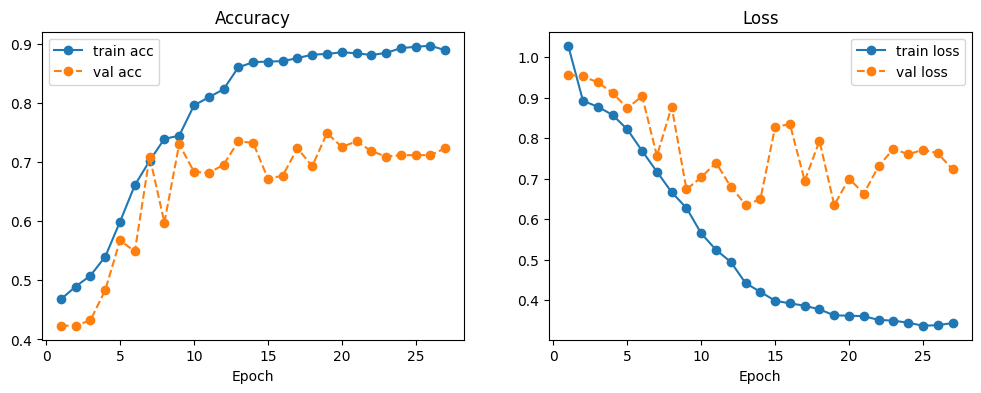

In [14]:
# CELL 7: visualize training progress
plot_history(history)


Runs the model on the entire validation dataset (images it has never seen during training).

Returns:

val_loss → how well the model fits the validation data (lower = better)

val_acc → accuracy on validation data (higher = better)

In [15]:
# CELL 8: evaluate the model on validation data
val_loss, val_acc = model.evaluate(val_ds)
print(f"✅ Validation Loss: {val_loss:.4f}")
print(f"✅ Validation Accuracy: {val_acc:.4f}")


14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 97ms/step - accuracy: 0.7397 - loss: 0.6441 
✅ Validation Loss: 0.6349
✅ Validation Accuracy: 0.7488


CELL 9 is responsible for finalizing and saving your trained model. During training, the ModelCheckpoint callback automatically saved the model each time the validation accuracy improved. This cell first checks if that best-performing checkpoint exists and, if so, loads it to ensure you’re using the model with the highest validation accuracy rather than the one from the last epoch (which could be slightly overfitted). After loading, it creates a folder in your Google Drive to permanently store the finalized model and saves it in the modern .keras format, which keeps the model’s architecture, learned weights, and optimizer configuration together in one portable file. This makes it easy to reload the exact same model later for evaluation, inference, or deployment without needing to retrain.

In [17]:
# CELL 9 (FIXED): load best checkpoint and save final model
import os
from tensorflow import keras

best_path = os.path.join(CHECKPOINT_PATH, "best_model.h5")

if os.path.exists(best_path):
    print("📦 Loading best model from checkpoint...")
    model = keras.models.load_model(best_path)
else:
    print("⚠️ No checkpoint found — saving current model as final.")

# Save final model in the new .keras format
FINAL_MODEL_PATH = "/content/drive/MyDrive/PotatoDiseaseDetection/final_model"
os.makedirs(FINAL_MODEL_PATH, exist_ok=True)

final_model_file = os.path.join(FINAL_MODEL_PATH, "potato_model.keras")
model.save(final_model_file)

print("✅ Final model saved to:", final_model_file)


📦 Loading best model from checkpoint...


✅ Final model saved to: /content/drive/MyDrive/PotatoDiseaseDetection/final_model/potato_model.keras


Loads a few representative images (one from each class).

Preprocesses them exactly like during training (resized + rescaled).

Uses your saved trained model to predict their disease class.

Displays the image along with its predicted class label and confidence score.



✅ Found 3 sample images for testing predictions
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


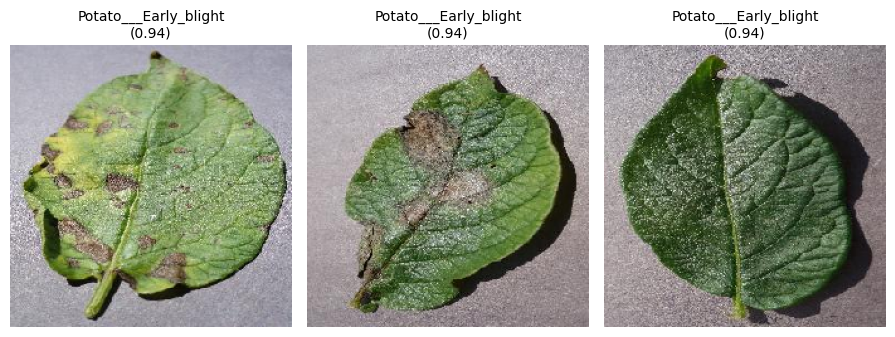

In [19]:
# CELL 10 (UPDATED): show predictions horizontally
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
import os

def predict_and_plot_horizontal(model, class_names, sample_paths, target_size=IMG_SIZE):
    plt.figure(figsize=(15, 4))  # wide figure for horizontal display

    for i, img_path in enumerate(sample_paths[:5]):  # show first 5 samples
        img = image.load_img(img_path, target_size=target_size)
        arr = image.img_to_array(img)
        arr = np.expand_dims(arr, axis=0)
        arr = arr / 255.0

        preds = model.predict(arr)
        pred_idx = np.argmax(preds[0])
        confidence = preds[0][pred_idx]

        plt.subplot(1, 5, i + 1)
        plt.imshow(img)
        plt.axis("off")
        plt.title(f"{class_names[pred_idx]}\n({confidence:.2f})", fontsize=10)

    plt.tight_layout()
    plt.show()

# Pick one sample image from each class
sample_paths = []
for cls in class_names:
    cls_dir = os.path.join(DATASET_DIR, cls)
    if os.path.isdir(cls_dir):
        files = [os.path.join(cls_dir, f) for f in os.listdir(cls_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        if files:
            sample_paths.append(files[0])

print(f"✅ Found {len(sample_paths)} sample images for testing predictions")

# Display predictions side-by-side
predict_and_plot_horizontal(model, class_names, sample_paths)


In [20]:
# CELL 11: save class labels and define inference helper
import json
import numpy as np
from tensorflow.keras.preprocessing import image

# Save class labels for later reference
LABELS_PATH = os.path.join(FINAL_MODEL_PATH, "labels.json")
with open(LABELS_PATH, "w") as f:
    json.dump(class_names, f)
print("✅ Saved class labels to:", LABELS_PATH)

# Simple inference helper
def infer_from_image(img_path, model, class_names, target_size=IMG_SIZE):
    img = image.load_img(img_path, target_size=target_size)
    arr = image.img_to_array(img)
    arr = np.expand_dims(arr, axis=0)
    arr = arr / 255.0

    preds = model.predict(arr)
    pred_idx = np.argmax(preds[0])
    confidence = float(preds[0][pred_idx])

    return {"predicted_class": class_names[pred_idx], "confidence": confidence}

# 🔍 Example usage
# test_image = "/content/drive/MyDrive/PotatoDiseaseDetection/PlantVillage/Potato___Early_blight/abc.jpg"
# result = infer_from_image(test_image, model, class_names)
# print(result)


✅ Saved class labels to: /content/drive/MyDrive/PotatoDiseaseDetection/final_model/labels.json
